In [3]:
# import useful libraries
import os #fornisce funzioni per interagire con il sistema operativo
import glob #trova file con pattern specifici, tipo cerca tutti i file .jpg
import numpy as np #per il calcolo numerico
import pandas as pd #per manipolare dati tabulari tipo exel
import matplotlib.pyplot as plt #per creare e grafici e visualizzazioni di dati
import scipy.io as sio # useful because ground truth labels are uploaded as .mat files
import cv2 # per cariche e processare le immagini
import matplotlib.patches as patches #per disegnare forme sopra le immagini
from PIL import Image
from scipy.stats import ttest_ind

In [34]:
df_images_Pannuke= pd.read_csv("df_images_Pannuke.csv")
df_nuclei_Pannuke = pd.read_csv("df_nuclei_Pannuke.csv")
df_dataset_Pannuke = pd.read_csv("df_dataset_Pannuke.csv")

df_images_Nuinsseg= pd.read_csv("df_images_Nuinsseg.csv")
df_nuclei_Nuinsseg= pd.read_csv("df_nuclei_Nuinsseg.csv")
df_dataset_Nuinsseg= pd.read_csv("df_dataset_Nuinsseg.csv")

df_images_Lizard = pd.read_csv("df_images_Lizard_processed.csv")
df_dataset = pd.read_csv("df_dataset.csv")  

In [9]:
# CONTROLLO SE LE IMMAGINI DI PANNUKE SONO 256 256
DATA_PATH_PANNUKE = 'data/PanNuke/'

image_paths_pannuke = (
    glob.glob(os.path.join(DATA_PATH_PANNUKE, "train", "images", "*.png")) +
    glob.glob(os.path.join(DATA_PATH_PANNUKE, "validate", "images", "*.png"))
)


sizes_Pannuke = set()

for img_path in image_paths_pannuke:
    img = Image.open(img_path)
    sizes_Pannuke.add(img.size)

print(f"Trovate {len(image_paths_pannuke)} immagini")
print("Dimensioni uniche presenti nel dataset:", sizes_Pannuke) 

Trovate 7901 immagini
Dimensioni uniche presenti nel dataset: {(256, 256)}


In [13]:
# CONTROLLO SE LE IMMAGINI DI LIZARD SONO 256 256
DATA_PATH =  'data/lizard/'
# Supponendo che il tuo array si chiami 'images'
# La forma (shape) di solito è [Numero_Immagini, Altezza, Larghezza, Canali]
images = np.load(os.path.join(DATA_PATH, 'images.npy'))
labels = np.load(os.path.join(DATA_PATH, 'labels.npy'))
patch_info = pd.read_csv(os.path.join(DATA_PATH, 'patch_info.csv'))

n_immagini = images.shape[0]
altezza = images.shape[1]
larghezza = images.shape[2]
canali = images.shape[3]

print(f" Numero totale di patch in Lizard (NumPy): {n_immagini}")
print(f" Dimensione di ogni patch: {larghezza}x{altezza}")

# Per simulare il tuo set di dimensioni:
sizes_Lizard = {(larghezza, altezza)}
print(" Dimensioni uniche presenti nel dataset:", sizes_Lizard) 


 Numero totale di patch in Lizard (NumPy): 4981
 Dimensione di ogni patch: 256x256
Dimensioni uniche presenti nel dataset: {(256, 256)}


In [14]:
# CONTROLLO SE LE IMMAGINI DI NUINSSEG SONO 256 256: FALSO SONO 512 512
DATA_PATH_NUINSSEG = 'data/nunsSeg'

folders = [
    "human bladder",
    "human brain",
    "human cardia",
    "human cerebellum",
    "human epiglottis",
    "human jejunum",
    "human kidney",
    "human liver",
    "human lung",
    "human melanoma",
    "human muscle",
    "human oesophagus",
    "human pancreas",
    "human peritoneum",
    "human placenta",
    "human pylorus",
    "human rectum",
    "human salivory gland",
    "human spleen",
    "human testis",
    "human tounge",
    "human tonsile",
    "human umbilical cord",
]

image_paths_nuinsseg = []
for folder in folders:
    image_paths_nuinsseg += glob.glob(os.path.join(DATA_PATH_NUINSSEG, folder, "tissue images", "*.png*"))

sizes_nuinsseg = set()

for img_path in image_paths_nuinsseg:
    img = Image.open(img_path)
    sizes_nuinsseg.add(img.size)

print(f"Trovate {len(image_paths_nuinsseg)} immagini")
print("Dimensioni uniche presenti nel dataset:", sizes_nuinsseg) 

Trovate 432 immagini
Dimensioni uniche presenti nel dataset: {(512, 512)}


In [32]:
df_img_pan = pd.read_csv("df_images_Pannuke.csv")
df_img_nu  = pd.read_csv("df_images_Nuinsseg.csv")
df_img_liz = pd.read_csv("df_images_Lizard_processed.csv") 

print("Densità Pannuke:", df_img_pan["density"].mean())
print("Densità Nuinsseg:", df_img_nu["density"].mean())
print("Densità Lizard:", df_img_liz["density"].mean()) 

Densità Pannuke: 1.492758006057382e-05
Densità Nuinsseg: 0.00017549373485421216
Densità Lizard: 0.0017457114623459773


In [40]:
df_img_pan = pd.read_csv("df_images_Pannuke.csv")
df_img_nu  = pd.read_csv("df_images_Nuinsseg.csv")
df_img_liz = pd.read_csv("df_images_Lizard_processed.csv") 

print("Densità media nuclei Pannuke:", df_img_pan["density"].mean())
print("Densità media nuclei Nuinsseg:", df_img_nu["density"].mean())
print("Densità media nuclei Lizard:", df_img_liz ["density"].mean()) 

Densità media nuclei Pannuke: 0.00031055044394597995
Densità media nuclei Nuinsseg: 0.00017549373485421216
Densità media nuclei Lizard: 0.0017457114623459773


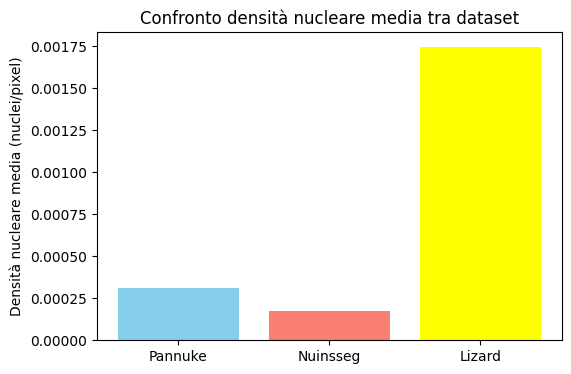

In [42]:
# CONFRONTO VIA VISIVA DENSITà MEDIA

import matplotlib.pyplot as plt

densities = [df_img_pan["density"].mean(), df_img_nu["density"].mean(), df_img_liz["density"].mean()]
datasets = ["Pannuke", "Nuinsseg", "Lizard"]

plt.figure(figsize=(6,4))
plt.bar(datasets, densities, color=["skyblue", "salmon", "yellow"])
plt.ylabel("Densità nucleare media (nuclei/pixel)")
plt.title("Confronto densità nucleare media tra dataset")
plt.show() 

In [44]:
# P_TEST

df_images_Pannuke = pd.read_csv("df_images_Pannuke.csv")
df_images_Nuinsseg = pd.read_csv("df_images_Nuinsseg.csv")
df_images_Lizard = pd.read_csv("df_images_Lizard_processed.csv")


dens_Pannuke = df_images_Pannuke["density"].values
dens_Nuinsseg = df_images_Nuinsseg["density"].values
dens_Lizard = df_images_Lizard["density"].values


# T-test indipendente nuinsseg e pannuke
t_stat, p_value = ttest_ind(dens_Pannuke, dens_Nuinsseg, equal_var=False)  # Welch's t-test

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("La differenza di densità nucleare media tra Nuinsseg e Pannuke è statisticamente significativa.")
else:
    print("La differenza di densità nucleare media tra Nuinsseg e Pannuke NON è statisticamente significativa.")

# T-test indipendente nuinsseg e lizard
t_stat, p_value = ttest_ind(dens_Lizard, dens_Nuinsseg, equal_var=False)  # Welch's t-test

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("La differenza di densità nucleare media tra Nuinsseg e Lizard è statisticamente significativa.")
else:
    print("La differenza di densità nucleare media tra Nuinsseg e Lizard NON è statisticamente significativa.")

# T-test indipendente pannuke e lizard
t_stat, p_value = ttest_ind(dens_Lizard, dens_Pannuke, equal_var=False)  # Welch's t-test

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("La differenza di densità nucleare media tra Pannuke e Lizard è statisticamente significativa.")
else:
    print("La differenza di densità nucleare media tra Pannuke e Lizard NON è statisticamente significativa.") 

T-statistic: 21.4413
P-value: 4.9077e-77
La differenza di densità nucleare media tra Nuinsseg e Pannuke è statisticamente significativa.
T-statistic: 105.0319
P-value: 0.0000e+00
La differenza di densità nucleare media tra Nuinsseg e Lizard è statisticamente significativa.
T-statistic: 102.0731
P-value: 0.0000e+00
La differenza di densità nucleare media tra Pannuke e Lizard è statisticamente significativa.


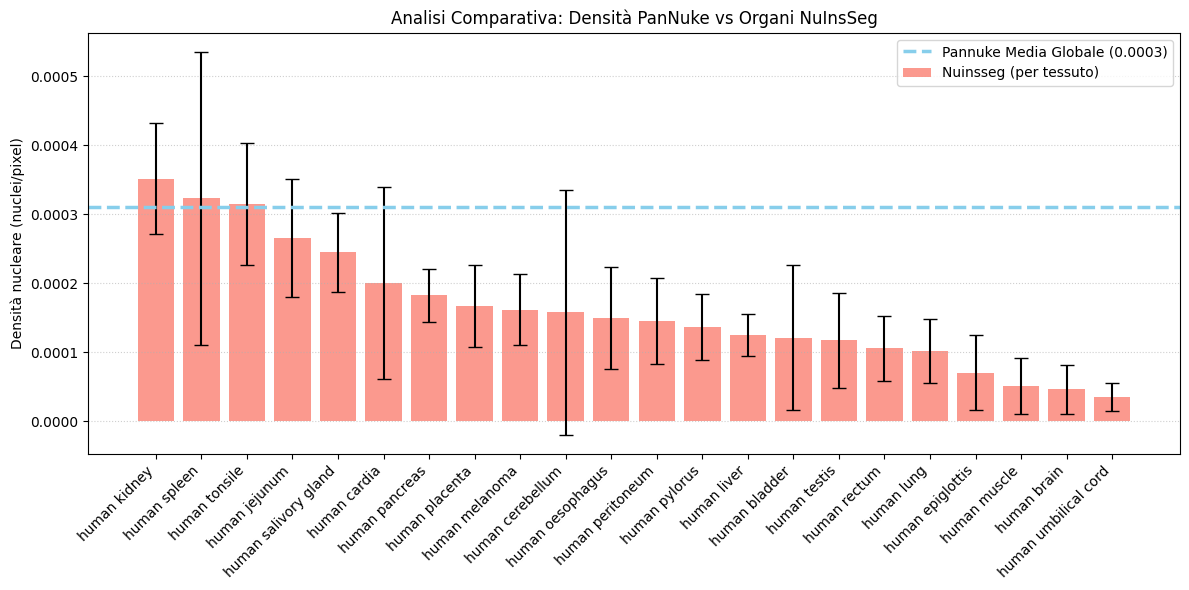

In [48]:
# CONFRONTO NELLO SPECIFICO CON TESSUTI NUINSSEG SPECIFICI

import pandas as pd
import matplotlib.pyplot as plt

# Carichiamo i dati
df_Pannuke = pd.read_csv("df_dataset_Pannuke.csv", index_col=0) # index_col=0 legge 'mean', 'std' come indici
df_Nuinsseg = pd.read_csv("df_tissue_summary_Nuinsseg.csv")

# 1. Recupero densità media Pannuke (prendiamo il valore della riga 'mean')
dens_Pannuke = df_Pannuke.loc["mean", "density"]

plt.figure(figsize=(12, 6))

# 2. Barre per Nuinsseg
# Nota: Verifica che i nomi siano "Tissue", "MeanDensity", "StdDensity"
plt.bar(df_Nuinsseg["Tissue"], 
        df_Nuinsseg["MeanDensity"], 
        yerr=df_Nuinsseg["StdDensity"],
        capsize=5, 
        color="salmon", 
        alpha=0.8,
        label="Nuinsseg (per tessuto)")

# 3. Linea orizzontale per Pannuke
plt.axhline(dens_Pannuke, color="skyblue", linestyle="--", linewidth=2.5, 
            label=f"Pannuke Media Globale ({dens_Pannuke:.4f})")

# Formattazione
plt.xticks(rotation=45, ha="right")
plt.ylabel("Densità nucleare (nuclei/pixel)")
plt.title("Analisi Comparativa: Densità PanNuke vs Organi NuInsSeg")
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show() 

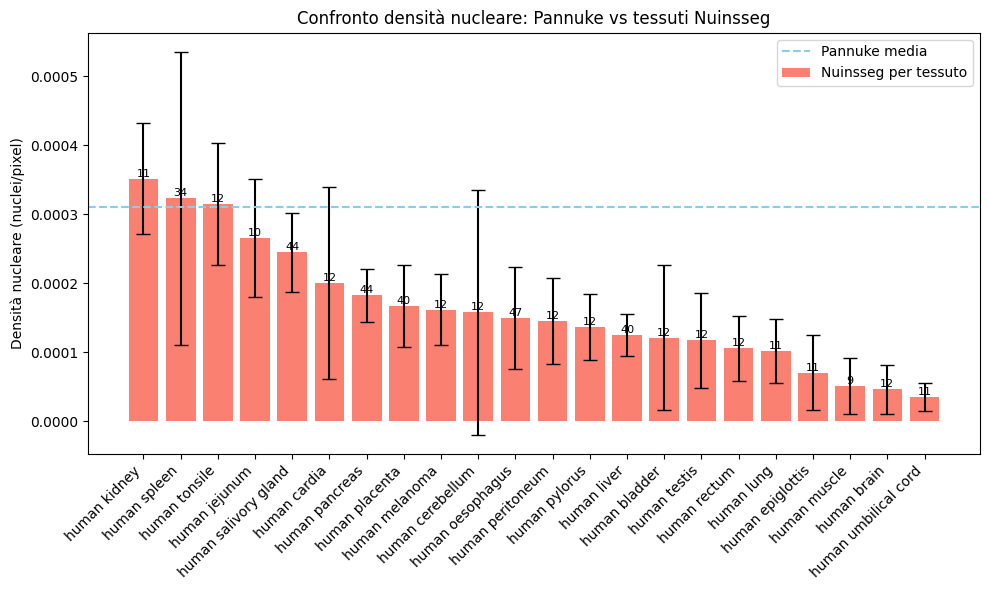

In [49]:
plt.figure(figsize=(10,6))
bars = plt.bar(df_Nuinsseg["Tissue"], df_Nuinsseg["MeanDensity"], yerr=df_Nuinsseg["StdDensity"],
        capsize=5, color="salmon", label="Nuinsseg per tessuto")

# ho aggiunto i numeri ma non si vedono
for bar, n in zip(bars, df_Nuinsseg["N_images"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(n),
             ha='center', va='bottom', fontsize=8)

plt.axhline(dens_Pannuke, color="skyblue", linestyle="--", label="Pannuke media")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Densità nucleare (nuclei/pixel)")
plt.title("Confronto densità nucleare: Pannuke vs tessuti Nuinsseg")
plt.legend()
plt.tight_layout()
plt.show() 

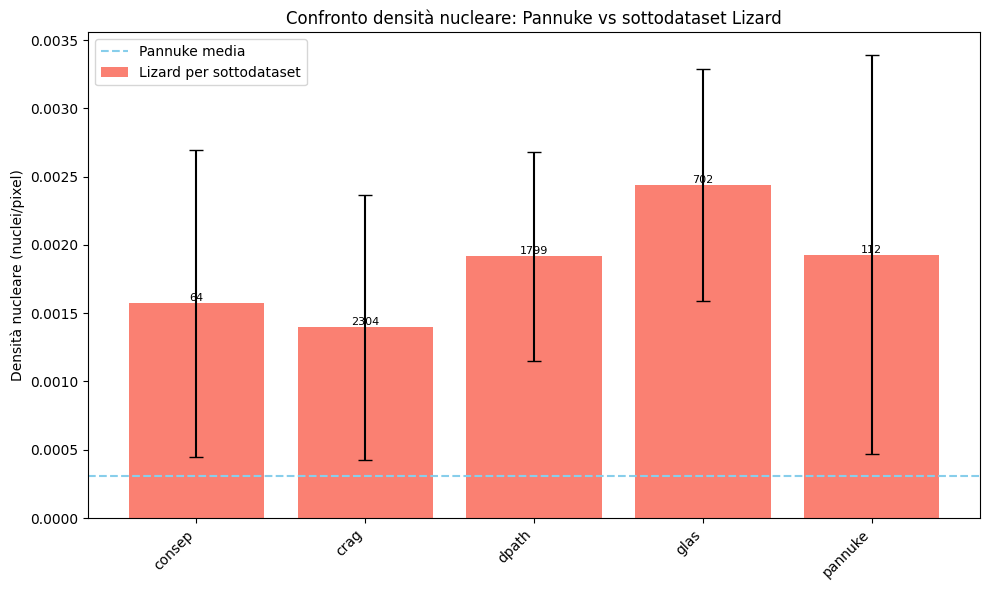

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Supponiamo che df_images_Lizard abbia le colonne: image_id, density
# E dens_Pannuke sia un singolo valore o una serie

# Calcolo il valore singolo per Pannuke
dens_Pannuke_val = dens_Pannuke.mean() if hasattr(dens_Pannuke, "__iter__") else dens_Pannuke

# Identifico i sottodataset di Lizard
subdatasets = ['consep', 'crag', 'dpath', 'glas', 'pannuke']
stats = []

for sd in subdatasets:
    df_sd = df_images_Lizard[df_images_Lizard['image_id'].str.startswith(sd)]
    mean_density = df_sd['density'].mean()
    std_density = df_sd['density'].std()
    n_images = len(df_sd)
    stats.append((sd, mean_density, std_density, n_images))

# Creo DataFrame dei risultati
df_Lizard_stats = pd.DataFrame(stats, columns=['Subdataset', 'MeanDensity', 'StdDensity', 'N_images'])

# Grafico
plt.figure(figsize=(10,6))
bars = plt.bar(df_Lizard_stats["Subdataset"], df_Lizard_stats["MeanDensity"],
               yerr=df_Lizard_stats["StdDensity"], capsize=5, color="salmon", label="Lizard per sottodataset")

# Aggiungo numero immagini sopra barre
for bar, n in zip(bars, df_Lizard_stats["N_images"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(n),
             ha='center', va='bottom', fontsize=8)

# Linea Pannuke media (ORA USO dens_Pannuke_val!)
plt.axhline(dens_Pannuke_val, color="skyblue", linestyle="--", label="Pannuke media")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Densità nucleare (nuclei/pixel)")
plt.title("Confronto densità nucleare: Pannuke vs sottodataset Lizard")
plt.legend()
plt.tight_layout()
plt.show() 


In [56]:
# CONFRONTO NUMERICO GLOBALE PANNUKE VS NUINSSEG

import pandas as pd

# Leggi i CSV
df_Pannuke = pd.read_csv("df_images_Pannuke.csv")
df_Nuinsseg = pd.read_csv("df_images_Nuinsseg.csv")
df_Lizard = pd.read_csv("df_images_Lizard_processed.csv")


# RGB medi globali
rgb_Pannuke = df_Pannuke[["R_mean", "G_mean", "B_mean"]].mean()
rgb_Nuinsseg = df_Nuinsseg[["R_mean", "G_mean", "B_mean"]].mean()
rgb_Lizard = df_Lizard[["R_mean", "G_mean", "B_mean"]].mean()


print("RGB medi Pannuke:\n", rgb_Pannuke)
print("\nRGB medi Nuinsseg:\n", rgb_Nuinsseg)
print("\nRGB medi Lizard:\n", rgb_Lizard)  

RGB medi Pannuke:
 R_mean    179.719999
G_mean    146.193431
B_mean    189.044232
dtype: float64

RGB medi Nuinsseg:
 R_mean    110.200060
G_mean     70.889226
B_mean    100.298706
dtype: float64

RGB medi Lizard:
 R_mean    194.968426
G_mean    154.255437
B_mean    201.362713
dtype: float64


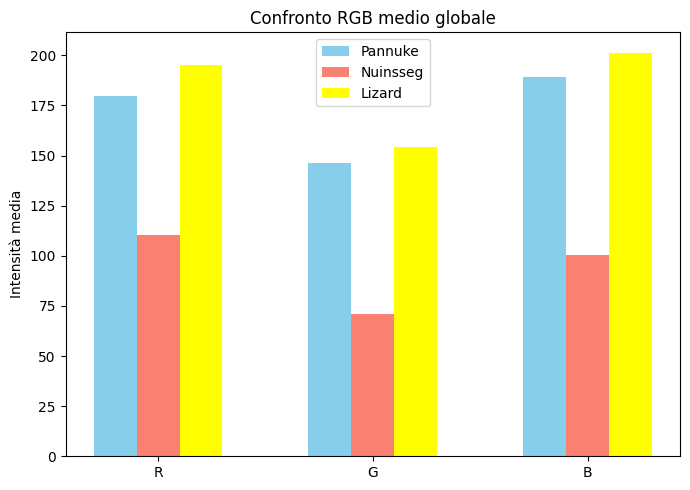

In [57]:
# CONFRONTO NUMERICO GLOBALE PANNUKE VS NUINSSEG


labels = ['R', 'G', 'B']
Pannuke_vals = rgb_Pannuke.values
Nuinsseg_vals = rgb_Nuinsseg.values
Lizard_vals = rgb_Lizard.values

x = np.arange(len(labels)) 
width = 0.2  

plt.figure(figsize=(7,5))
plt.bar(x - width, Pannuke_vals, width, label='Pannuke', color='skyblue')
plt.bar(x, Nuinsseg_vals, width, label='Nuinsseg', color='salmon')
plt.bar(x + width, Lizard_vals, width, label='Lizard', color='yellow')


plt.xticks(x, labels)
plt.ylabel('Intensità media')
plt.title('Confronto RGB medio globale')
plt.legend()
plt.tight_layout()
plt.show()
